##Visualize GELECTRA emotion results (titles)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

In [2]:
# Paths: support running from Sentiment_Analysis/ or repo root
_cwd = Path.cwd().resolve()
_c1 = _cwd / "outputs" / "emotion_full_results.csv"
_c2 = _cwd / "Sentiment_Analysis" / "outputs" / "emotion_full_results.csv"
if _c1.is_file():
    DATA_PATH, BASE_DIR = _c1, _cwd
elif _c2.is_file():
    DATA_PATH, BASE_DIR = _c2, _cwd / "Sentiment_Analysis"
else:
    DATA_PATH = _c1
    BASE_DIR = _cwd

FIG_DIR = BASE_DIR / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("CSV:", DATA_PATH)
print("Figures:", FIG_DIR)

CSV: /Users/gretawette/Documents/Thesis/Sentiment_Analysis/outputs/emotion_full_results.csv
Figures: /Users/gretawette/Documents/Thesis/Sentiment_Analysis/outputs/figures


### Load data

In [3]:
df = pd.read_csv(DATA_PATH, encoding="utf-8", low_memory=False)
df.columns = df.columns.astype(str).str.replace("\ufeff", "", regex=False).str.strip()

OUTLET_COL = "source" if "source" in df.columns else None
if OUTLET_COL is None:
    for c in df.columns:
        if c.lower() in ("source", "outlet", "datasource"):
            OUTLET_COL = c
            break
if OUTLET_COL is None:
    raise KeyError(f"No outlet column found. Columns: {list(df.columns)}")

EMOTION_COLS = [
    "emotion_anger",
    "emotion_fear",
    "emotion_disgust",
    "emotion_sadness",
    "emotion_joy",
    "emotion_enthusiasm",
    "emotion_pride",
    "emotion_hope",
]
EMOTION_SHORT = [c.replace("emotion_", "") for c in EMOTION_COLS]

for c in EMOTION_COLS:
    if c not in df.columns:
        raise KeyError(f"Missing {c}; got {list(df.columns)}")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["year_month"] = df["Date"].dt.to_period("M").dt.to_timestamp()

print(f"Rows: {len(df):,}")
print(f"Outlets ({OUTLET_COL}): {df[OUTLET_COL].nunique()}")
df[[OUTLET_COL] + EMOTION_COLS[:3]].head()

Rows: 20,325
Outlets (source): 7


,source,emotion_anger,emotion_fear,emotion_disgust
0,Antispiegel,0.539485,0.404731,0.002879
1,Antispiegel,0.950452,0.007384,0.001227
2,Antispiegel,0.990249,0.003278,0.000832
3,Antispiegel,0.290512,0.651681,0.008496
4,Antispiegel,0.953203,0.006887,0.001267


In [4]:
# Emotion colours (aligned with inspiration notebook)
emotion_colors = {
    "anger": "#e66101",
    "fear": "#5e3c99",
    "disgust": "#1b7837",
    "sadness": "#2166ac",
    "joy": "#fdb863",
    "enthusiasm": "#b2abd2",
    "pride": "#d01c8b",
    "hope": "#80cdc1",
}

# Distinct colours for outlets (Tab10 + extras if needed)
outlets_sorted = sorted(df[OUTLET_COL].dropna().unique())
pal = sns.color_palette("tab10", n_colors=max(10, len(outlets_sorted)))
outlet_colors = {o: pal[i % len(pal)] for i, o in enumerate(outlets_sorted)}

<hr style="opacity:0.35">

### Summary statistics

In [5]:
summary_stats = df[EMOTION_COLS].describe().T
summary_stats.index = EMOTION_SHORT
summary_stats = summary_stats.rename(
    columns={
        "count": "N",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "50%": "Median",
        "max": "Max",
    }
).round(4)
summary_stats

,N,Mean,Std,Min,25%,Median,75%,Max
anger,20325.0,0.5335,0.3466,0.0004,0.2014,0.5416,0.8906,0.9967
fear,20325.0,0.1411,0.1839,0.0002,0.0137,0.0574,0.1942,0.8264
disgust,20325.0,0.0135,0.0442,0.0001,0.0014,0.0030,0.0065,0.5072
sadness,20325.0,0.0974,0.1728,0.0002,0.0071,0.0261,0.0918,0.9330
joy,20325.0,0.0710,0.1885,0.0000,0.0005,0.0020,0.0208,0.9828
enthusiasm,20325.0,0.0180,0.0386,0.0000,0.0005,0.0027,0.0168,0.5741
pride,20325.0,0.0296,0.0845,0.0000,0.0003,0.0017,0.0161,0.8406
hope,20325.0,0.0958,0.1927,0.0001,0.0011,0.0087,0.0747,0.9337


In [6]:
total_titles = len(df)
outlet_summary = (
    df.groupby(OUTLET_COL, observed=True)
    .size()
    .reset_index(name="N")
    .sort_values("N", ascending=False)
)
outlet_summary["Share (%)"] = (outlet_summary["N"] / total_titles * 100).round(2)
outlet_summary

,source,N,Share (%)
5,Tagesschau,6296,30.98
4,RT_de,4556,22.42
3,Nius,3267,16.07
6,Tichys_Einblick,2739,13.48
2,Deutschlandkurier,1484,7.30
1,Compact,1418,6.98
0,Antispiegel,565,2.78


In [8]:
print("Dominant emotion (full corpus):")
print(df["emotion_dominant"].value_counts(normalize=True).round(4) * 100)

print("\nDominant emotion by outlet (share within each outlet, %):")
dominant_share = pd.crosstab(
    df[OUTLET_COL], df["emotion_dominant"], normalize="index"
).round(4) * 100
display(dominant_share)

Dominant emotion (full corpus):
emotion_dominant
anger         60.36
fear          11.26
hope          10.06
sadness        8.22
joy            7.63
pride          1.84
disgust        0.56
enthusiasm     0.07
Name: proportion, dtype: float64

Dominant emotion by outlet (share within each outlet, %):


emotion_dominant,anger,disgust,enthusiasm,fear,hope,joy,pride,sadness
source,,,,,,,,
Antispiegel,60.71,0.00,0.00,18.76,8.85,4.96,0.35,6.37
Compact,63.12,0.49,0.07,9.45,5.92,8.74,3.81,8.39
Deutschlandkurier,72.04,0.88,0.34,7.61,7.68,4.11,1.89,5.46
Nius,65.75,2.33,0.09,7.90,6.27,5.66,1.74,10.25
RT_de,60.84,0.26,0.02,14.35,8.54,7.75,1.21,7.02
Tagesschau,49.25,0.00,0.06,12.28,15.49,10.64,1.95,10.32
Tichys_Einblick,70.87,0.22,0.04,9.13,8.32,4.75,1.97,4.71


<hr style="opacity:0.35">

### Visualizations — corpus-wide mean probabilities

Same idea as inspiration: **average softmax score per title**, then **mean across all titles**.

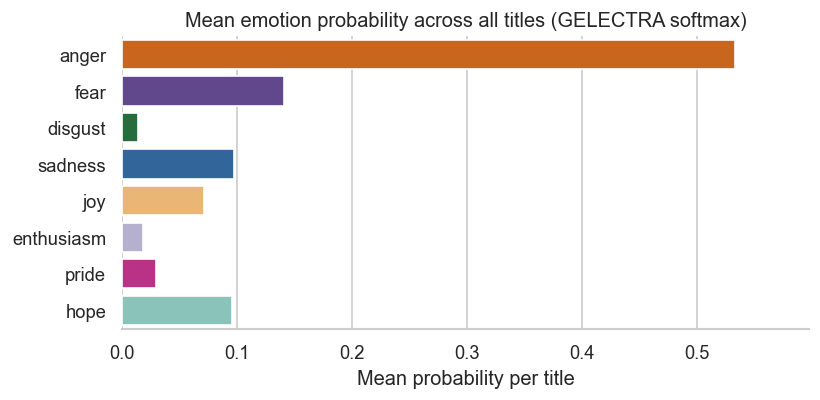

In [9]:
emotion_means = df[EMOTION_COLS].mean()
plot_df = pd.DataFrame({"emotion": EMOTION_SHORT, "mean_prob": emotion_means.values})

plt.figure(figsize=(7, 3.5))
sns.barplot(
    data=plot_df,
    x="mean_prob",
    y="emotion",
    hue="emotion",
    dodge=False,
    palette=[emotion_colors[e] for e in plot_df["emotion"]],
    legend=False,
)
plt.title("Mean emotion probability across all titles (GELECTRA softmax)")
plt.xlabel("Mean probability per title")
plt.ylabel("")
plt.xlim(0, plot_df["mean_prob"].max() * 1.12)
sns.despine(left=True)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_mean_emotion_corpus.png", bbox_inches="tight")
plt.show()

### By outlet: heatmap of mean probabilities

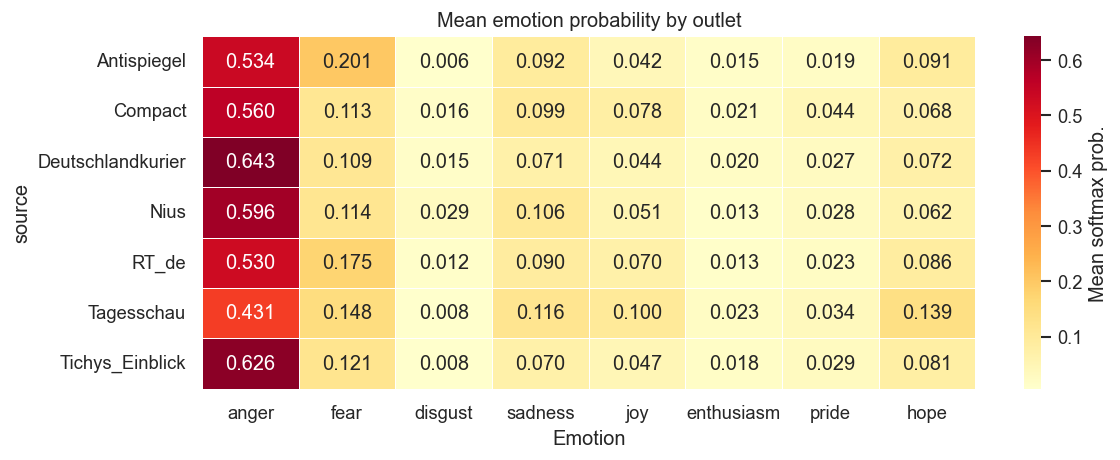

In [10]:
mean_by_outlet = df.groupby(OUTLET_COL, observed=True)[EMOTION_COLS].mean()
mean_by_outlet.columns = EMOTION_SHORT
mean_by_outlet = mean_by_outlet.sort_index()

plt.figure(figsize=(10, max(4, 0.35 * len(mean_by_outlet))))
sns.heatmap(
    mean_by_outlet,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean softmax prob."},
)
plt.title("Mean emotion probability by outlet")
plt.ylabel(OUTLET_COL)
plt.xlabel("Emotion")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_heatmap_mean_by_outlet.png", bbox_inches="tight")
plt.show()

### Grouped bars: mean probability per emotion, faceted by outlet

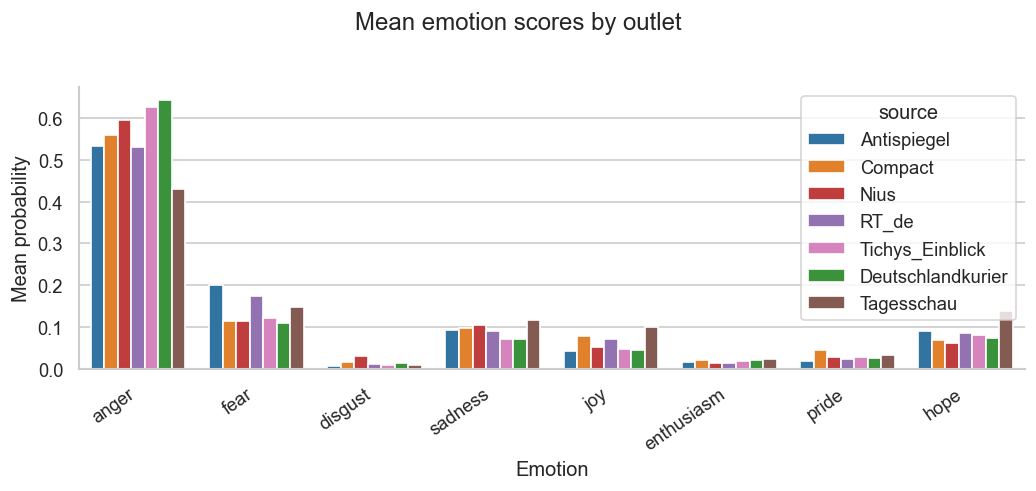

In [11]:
melt_outlet = df.melt(
    id_vars=[OUTLET_COL],
    value_vars=EMOTION_COLS,
    var_name="emotion_col",
    value_name="prob",
)
melt_outlet["emotion"] = melt_outlet["emotion_col"].str.replace("emotion_", "")

g = sns.catplot(
    data=melt_outlet,
    kind="bar",
    x="emotion",
    y="prob",
    hue=OUTLET_COL,
    palette=outlet_colors,
    height=4,
    aspect=2.2,
    legend_out=False,
    errorbar=None,
    estimator="mean",
)
g.set_xticklabels(rotation=35, ha="right")
g.set_axis_labels("Emotion", "Mean probability")
g.figure.suptitle("Mean emotion scores by outlet", y=1.02)
plt.tight_layout()
g.savefig(FIG_DIR / "03_grouped_bar_emotion_by_outlet.png", bbox_inches="tight")
plt.show()

### Dominant-emotion shares by outlet (%)

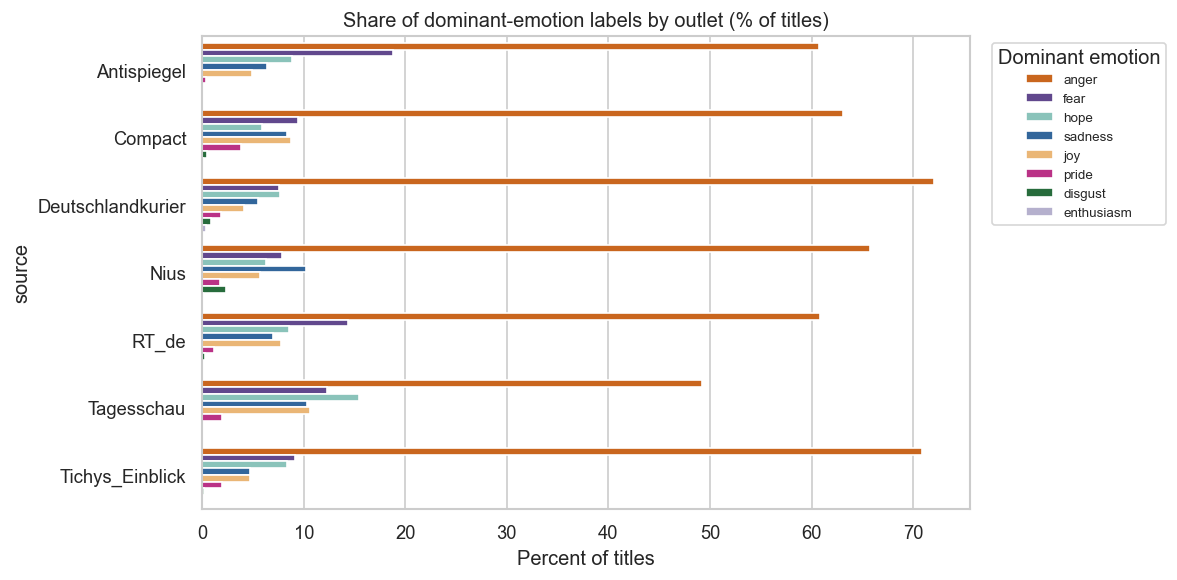

In [12]:
dom_share = (
    df.groupby(OUTLET_COL, observed=True)["emotion_dominant"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=dom_share,
    x="pct",
    y=OUTLET_COL,
    hue="emotion_dominant",
    palette=emotion_colors,
    dodge=True,
)
plt.title("Share of dominant-emotion labels by outlet (% of titles)")
plt.xlabel("Percent of titles")
plt.legend(title="Dominant emotion", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_dominant_emotion_share_by_outlet.png", bbox_inches="tight")
plt.show()

### Example: distribution of **anger** and **fear** by outlet (boxplot)

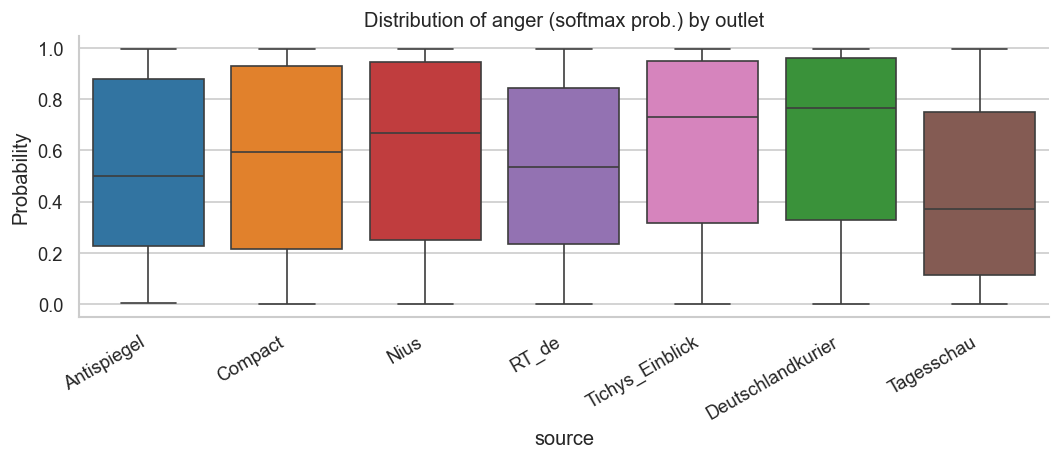

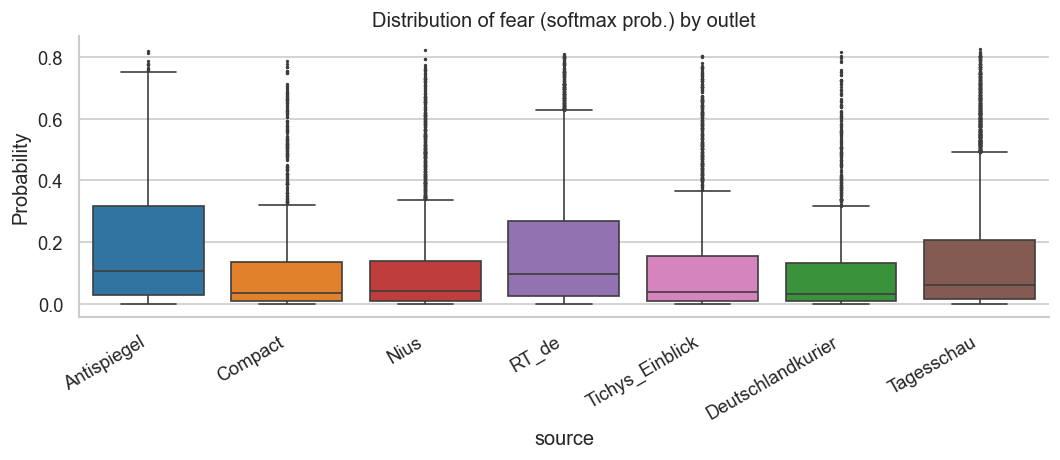

In [13]:
for emo, col in [("anger", "emotion_anger"), ("fear", "emotion_fear")]:
    plt.figure(figsize=(9, 4))
    sns.boxplot(
        data=df,
        x=OUTLET_COL,
        y=col,
        hue=OUTLET_COL,
        palette=outlet_colors,
        dodge=False,
        legend=False,
        fliersize=1,
    )
    plt.title(f"Distribution of {emo} (softmax prob.) by outlet")
    plt.xlabel(OUTLET_COL)
    plt.ylabel("Probability")
    plt.xticks(rotation=30, ha="right")
    sns.despine()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"05_box_{emo}_by_outlet.png", bbox_inches="tight")
    plt.show()

/var/folders/fw/05h50b4559n_s_5qbnxzd4w80000gn/T/ipykernel_50292/1223255041.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


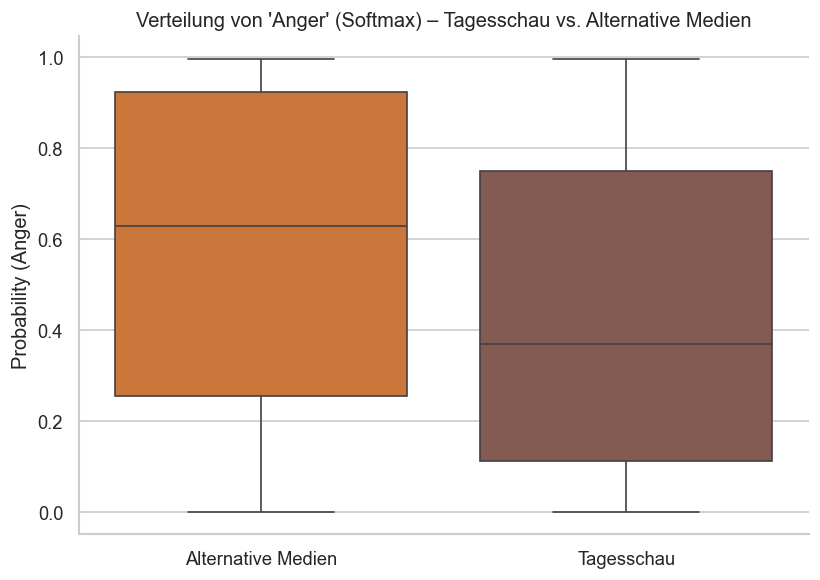

In [17]:
# Combine all alternative outlets vs Tagesschau for anger boxplot

# Define which are the alternative outlets
tagesschau_name = "Tagesschau"
alt_outlets = [o for o in df[OUTLET_COL].unique() if o != tagesschau_name]

# Create a new column for group
df["outlet_group"] = df[OUTLET_COL].apply(lambda x: "Tagesschau" if x == tagesschau_name else "Alternative Medien")

plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="outlet_group",
    y="emotion_anger",
    palette={
        "Tagesschau": outlet_colors[tagesschau_name] if tagesschau_name in outlet_colors else "#193b5b",
        "Alternative Medien": "#e37222",
    },
    fliersize=1,
)
plt.title("Verteilung von 'Anger' (Softmax) – Tagesschau vs. Alternative Medien")
plt.xlabel("")
plt.ylabel("Probability (Anger)")
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "06_box_anger_tagesschau_vs_alternative.png", bbox_inches="tight")
plt.show()


### Export summary tables (optional)

Saved next to figures for use in the thesis.

In [ ]:
summary_stats.to_csv(FIG_DIR / "../tables_emotion_summary_stats.csv")
mean_by_outlet.to_csv(FIG_DIR / "../tables_mean_emotion_by_outlet.csv")
outlet_summary.to_csv(FIG_DIR / "../tables_outlet_counts.csv", index=False)
print("Wrote CSV tables to outputs/tables_*.csv")